# Project 2 - Task 2.1 Notebook


In [109]:
import ax
import cv2
import sns
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import warnings
import torch
from ultralytics import YOLO
from transformers import pipeline
from torchvision.datasets import VOCDetection
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor
from transformers import DetrForObjectDetection, DetrImageProcessor
import pandas as pd
import seaborn as sns
import os

In [110]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [111]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device", device)

Using device cuda:0


In [112]:
# Mapping between class IDs and labels

label2id = {'Plastic bag & wrapper': 0,
  'Cigarette': 1,
  'Bottle': 2,
  'Bottle cap': 3,
  'Can': 4,
  'Carton': 5}

id2label = {v: k for k, v in label2id.items()}
label2id, id2label
categories = list(id2label.values())

image_size = 480
checkpoint_rtdetr = "PekingU/rtdetr_r50vd"

In [113]:
from transformers import AutoImageProcessor

# Instantiate the image processor
image_processor = AutoImageProcessor.from_pretrained(
    checkpoint_rtdetr,
    do_resize=True,     # Resize the images to the expected size
    size={"width": image_size, "height": image_size},
    use_fast=True,      # Use the fast version of the processor
)

In [114]:
from taco_dataset import TACODETRDetectionDataset
train_dataset = TACODETRDetectionDataset(
    img_folder="/home/jb/Desktop/Projects/CV/cv-project2/taco",
    ann_file="/home/jb/Desktop/Projects/CV/cv-project2/taco/annotations_train.json",
    processor=image_processor,
)

validation_dataset = TACODETRDetectionDataset(
    img_folder="/home/jb/Desktop/Projects/CV/cv-project2/taco",
    ann_file="/home/jb/Desktop/Projects/CV/cv-project2/taco/annotations_val.json",
    processor=image_processor,
)

test_dataset = TACODETRDetectionDataset(
    img_folder="/home/jb/Desktop/Projects/CV/cv-project2/taco",
    ann_file="/home/jb/Desktop/Projects/CV/cv-project2/taco/annotations_test.json",
    processor=image_processor,
)


# Inpsect a sample from the training dataset
train_dataset[0]

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


{'pixel_values': tensor([[[0.2784, 0.3059, 0.3373,  ..., 0.1333, 0.1373, 0.1176],
          [0.3294, 0.3059, 0.3098,  ..., 0.1216, 0.1255, 0.1216],
          [0.3294, 0.3216, 0.3176,  ..., 0.1176, 0.1333, 0.1098],
          ...,
          [0.2549, 0.2745, 0.2667,  ..., 0.4471, 0.4627, 0.4510],
          [0.2824, 0.2706, 0.2706,  ..., 0.4196, 0.4078, 0.4039],
          [0.3137, 0.2863, 0.3255,  ..., 0.4510, 0.4196, 0.4039]],
 
         [[0.1451, 0.1725, 0.2039,  ..., 0.1059, 0.1137, 0.0902],
          [0.1961, 0.1765, 0.1843,  ..., 0.1020, 0.1059, 0.1020],
          [0.2039, 0.2000, 0.1961,  ..., 0.1020, 0.1137, 0.0902],
          ...,
          [0.2235, 0.2392, 0.2275,  ..., 0.3882, 0.4039, 0.3922],
          [0.2392, 0.2275, 0.2275,  ..., 0.3608, 0.3529, 0.3490],
          [0.2627, 0.2392, 0.2824,  ..., 0.4039, 0.3725, 0.3569]],
 
         [[0.1412, 0.1647, 0.1961,  ..., 0.1373, 0.1412, 0.1216],
          [0.1922, 0.1686, 0.1725,  ..., 0.1255, 0.1294, 0.1255],
          [0.1961, 0.188

In [115]:
def get_dataset_stats(dataset, split, id2label):
    coco = dataset.coco_dataset.coco
    ann_ids = coco.getAnnIds()
    anns = coco.loadAnns(ann_ids)

    cat_ids = [ann['category_id'] for ann in anns]
    names = [id2label[c] for c in cat_ids]

    return pd.DataFrame({
        'Class': names,
        'Split': split
    })


In [116]:
df_train = get_dataset_stats(train_dataset, 'Train', id2label)
df_val = get_dataset_stats(validation_dataset, 'Validation', id2label)
df_test = get_dataset_stats(test_dataset, 'Test', id2label)

df = pd.concat([df_train, df_val, df_test])
stats = df.groupby(['Class', 'Split']).size().reset_index(name='Count')


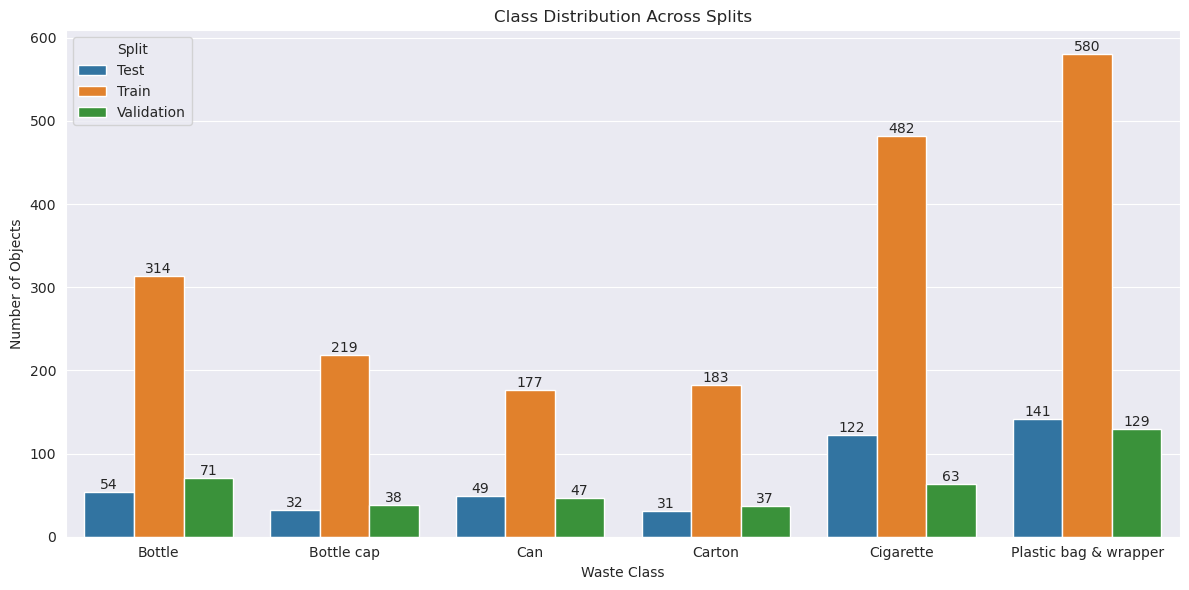

In [117]:
os.makedirs('results/task2_1', exist_ok=True)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=stats, x='Class', y='Count', hue='Split')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Class Distribution Across Splits')
plt.ylabel('Number of Objects')
plt.xlabel('Waste Class')
plt.tight_layout()
plt.savefig('results/task2_1/class_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()


Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (4, 4)
Categories shape: (4,)


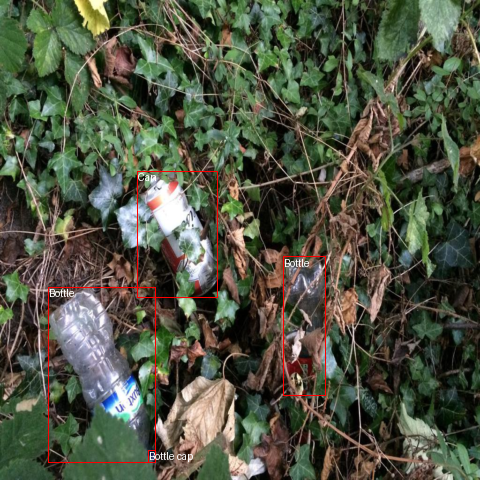

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (10, 4)
Categories shape: (10,)


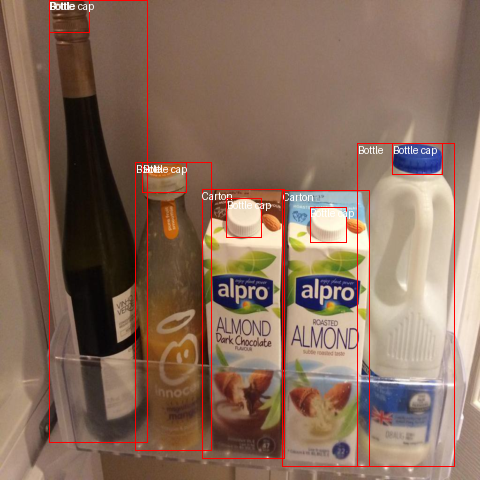

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


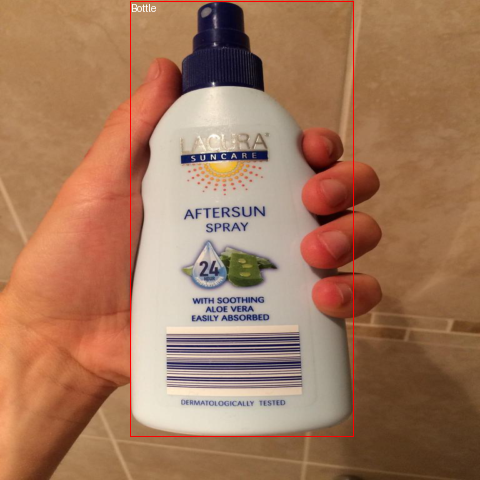

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


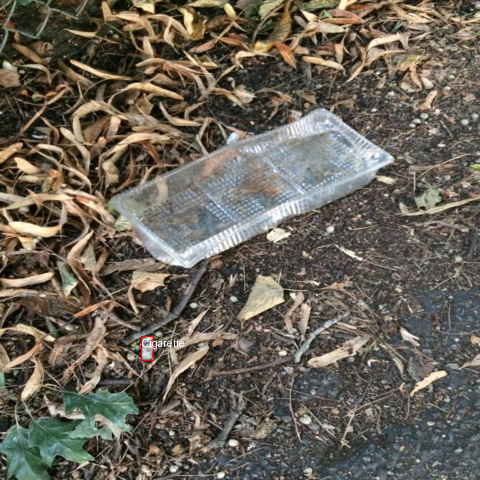

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (2, 4)
Categories shape: (2,)


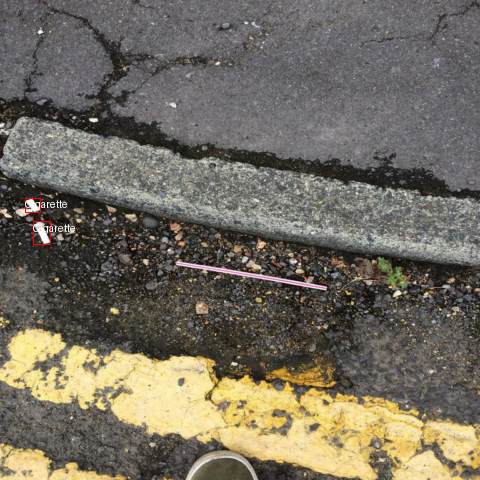

In [118]:
from PIL import ImageDraw

for i in [3, 10, 11,18, 34]:
    sample = train_dataset[i]

    # De-normalize image
    image = sample["pixel_values"]
    print("Image tensor shape:", image.shape)
    image = image.numpy().transpose(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min()) * 255.
    image = Image.fromarray(image.astype(np.uint8))

    # Convert boxes from [center_x, center_y, width, height] to [x, y, width, height] for visualization
    boxes = sample["labels"]["boxes"].numpy()
    print("Boxes shape:", boxes.shape)
    boxes[:, :2] = boxes[:, :2] - boxes[:, 2:] / 2
    w, h = image.size
    boxes = boxes * np.array([w, h, w, h])[None]

    categories = sample["labels"]["class_labels"].numpy()
    print("Categories shape:", categories.shape)

    # Draw boxes and labels on image
    draw = ImageDraw.Draw(image)
    for box, category in zip(boxes, categories):
        x, y, w, h = box
        draw.rectangle([x, y, x + w, y + h], outline="red", width=1)
        draw.text((x, y), id2label[category], fill="white")

    display(image)
    image.save(f"results/task2_1/sample_{i}.pdf")